# **LangGraph Concepts & First Graph**

In [1]:
from typing import TypedDict;

class MyState(TypedDict): # State
    name: str;
    greeting: str;
    farewell: str;

def greet_node(state: MyState) -> dict: # Node

    """Node 1 — Reads name, produces a greeting"""

    greeting = f"Hello, {state["name"]}! Welcome to LangGraph.👋";

    print(f"[greet_node] {greeting}");

    return {"greeting": greeting};

In [2]:
def farewell_node(state: MyState) -> dict:

    """Node 2 — Reads name, produces a farewell"""

    farewell = f"Goodbye, {state["name"]}! See you next time.🙌";

    print(f"[farewell_node] {farewell}");
    
    return {"farewell": farewell};

In [3]:
from langgraph.graph import StateGraph, START, END;

builder = StateGraph(MyState);

builder.add_node("greet", greet_node);

builder.add_node("farewell", farewell_node);

builder.add_edge(START, "greet");

builder.add_edge("greet", "farewell");

builder.add_edge("farewell", END);

graph = builder.compile(); # Create Graph

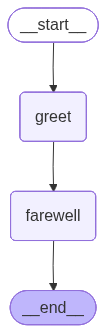

In [4]:
from IPython.display import Image, display; # Visualize Graph

display(Image(graph.get_graph().draw_mermaid_png())); # START → Greet → Farewell → END

In [5]:
result = graph.invoke(
    {
        "name": "Ahmed",
        "greeting": "",
        "farewell": ""
    }
);

print("\n✅ Final State:");

print(f"greeting : {result["greeting"]}");

print(f"farewell : {result["farewell"]}");

print("\n✅ Complete Result");

print(f"{result}");

[greet_node] Hello, Ahmed! Welcome to LangGraph.👋
[farewell_node] Goodbye, Ahmed! See you next time.🙌

✅ Final State:
greeting : Hello, Ahmed! Welcome to LangGraph.👋
farewell : Goodbye, Ahmed! See you next time.🙌

✅ Complete Result
{'name': 'Ahmed', 'greeting': 'Hello, Ahmed! Welcome to LangGraph.👋', 'farewell': 'Goodbye, Ahmed! See you next time.🙌'}


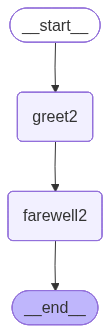

In [6]:
class MyState2(TypedDict): # State
    name: str;
    greeting: str;
    farewell: str;

builder = StateGraph(MyState2);

builder.add_node("greet2", greet_node);

builder.add_node("farewell2", farewell_node);

builder.set_entry_point("greet2"); # Start Or Entry Point Must Be Require

builder.add_edge("greet2", "farewell2");

builder.set_finish_point("farewell2");

graph2 = builder.compile();

display(Image(graph2.get_graph().draw_mermaid_png()));

In [7]:
result = graph2.invoke(
    {
        "name": "Ahmed Shaykh",
        "greeting": "",
        "farewell": ""
    }
);

print("\n✅ Final State:");

print(f"greeting : {result["greeting"]}");

print(f"farewell : {result["farewell"]}");

print("\n✅ Complete Result");

print(f"{result}");

[greet_node] Hello, Ahmed Shaykh! Welcome to LangGraph.👋
[farewell_node] Goodbye, Ahmed Shaykh! See you next time.🙌

✅ Final State:
greeting : Hello, Ahmed Shaykh! Welcome to LangGraph.👋
farewell : Goodbye, Ahmed Shaykh! See you next time.🙌

✅ Complete Result
{'name': 'Ahmed Shaykh', 'greeting': 'Hello, Ahmed Shaykh! Welcome to LangGraph.👋', 'farewell': 'Goodbye, Ahmed Shaykh! See you next time.🙌'}
